# Listings — Diagnóstico de Limpieza y Tratamiento ETL

Pipeline **bronze → silver** sobre el dataset de listings de Airbnb en Ciudad de México: un
scrape de **26,401 anuncios y 77 columnas** capturado entre el 25 de junio y el 2 de julio de 2025.

El notebook se ejecuta de arriba a abajo y está dividido en dos mitades. Primero se **diagnostica
el dato crudo** —duplicados, valores faltantes, formatos de texto y valores atípicos— y después se
aplican las **transformaciones**, cada una acompañada de la evidencia que la justifica. Al final se
guarda la tabla curada en la capa silver y las figuras en `reports/figures`.

In [1]:
import ast
import re
import unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
matplotlib.rcParams["figure.dpi"] = 110

# Carpetas de salida del notebook
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
Path("../data/silver").mkdir(parents=True, exist_ok=True)

## 1. Ingesta — capa bronze

Se lee el archivo crudo tal como llegó, sin conversiones implícitas: `price`, las tasas con `%` y
las columnas que guardan listas se dejan como texto para poder revisar su formato original antes
de transformarlas.

El archivo tiene **26,401 filas y 77 columnas**. De ellas **34 son de tipo `object`** (texto), 22
`float64`, 20 `int64` y una booleana; es decir, casi la mitad del dataset llega como texto y buena
parte del trabajo de limpieza consiste en devolverle a cada columna su tipo real.

In [2]:
df_raw = pd.read_csv("../data/bronze/listings.csv", sep=",", encoding="utf-8", low_memory=False)
df_raw.head()

,_id,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,host_neighbourhood,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,68e868bb1d1fc3fd4a01f6cb,35797,https://www.airbnb.com/rooms/35797,20250625031918,2025-06-26,city scrape,Villa Dante,"Dentro de Villa un estudio de arte con futon, ...","Santa Fe Shopping Mall, Interlomas Park and th...",https://a0.muscache.com/pictures/f395ab78-1185...,153786,https://www.airbnb.com/users/show/153786,Dici,2010-06-28,"Mexico City, Mexico","Master in visual arts, film photography & Mark...",NaN,NaN,NaN,False,https://a0.muscache.com/im/pictures/user/00de1...,https://a0.muscache.com/im/pictures/user/00de1...,1.0,1.0,"['email', 'phone', 'work_email']",True,True,"Mexico City, D.f., Mexico",Cuajimalpa de Morelos,19.38283,-99.27178,Entire villa,Entire home/apt,2,1.0,1 bath,1.0,1.0,"['Kitchen', 'Resort access', 'Hot water', 'Cou...","$3,799.00",1,7,1.0,1.0,7.0,7.0,1.0,7.0,True,29,59,89,364,2025-06-26,0,0,0,188,0,0,0.0,False,1,1,0,0,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,68e868bb1d1fc3fd4a01f6cc,44616,https://www.airbnb.com/rooms/44616,20250625031918,2025-07-01,city scrape,Condesa Haus,A new concept of hosting in mexico through a b...,NaN,https://a0.muscache.com/pictures/251410/ec75fe...,196253,https://www.airbnb.com/users/show/196253,Fernando,2010-08-09,"Mexico City, Mexico",Condesa Haus Rentals offers independent stud...,within an hour,100%,91%,False,https://a0.muscache.com/im/users/196253/profil...,https://a0.muscache.com/im/users/196253/profil...,13.0,13.0,"['email', 'phone', 'work_email']",True,True,NaN,Cuauhtémoc,19.41162,-99.17794,Entire home,Entire home/apt,14,5.5,5.5 baths,5.0,8.0,"['Free street parking', 'Free parking on premi...","$18,000.00",1,180,1.0,1.0,180.0,180.0,1.0,180.0,True,29,59,89,360,2025-07-01,65,1,0,179,0,6,108000.0,False,9,4,2,0,Condesa,2011-11-09,2025-01-01,4.59,4.56,4.70,4.87,4.78,4.98,4.47,0.39
2,68e868bb1d1fc3fd4a01f6cd,56074,https://www.airbnb.com/rooms/56074,20250625031918,2025-07-01,city scrape,Great space in historical San Rafael,This great apartment is located in one of the ...,Very traditional neighborhood with all service...,https://a0.muscache.com/pictures/3005118/60dac...,265650,https://www.airbnb.com/users/show/265650,Maris,2010-10-19,"Mexico City, Mexico",I am a University Professor now retired after ...,within a few hours,100%,100%,False,https://a0.muscache.com/im/users/265650/profil...,https://a0.muscache.com/im/users/265650/profil...,1.0,5.0,"['email', 'phone']",True,True,"Mexico City, DF, Mexico",Cuauhtémoc,19.43977,-99.15605,Entire condo,Entire home/apt,2,1.0,1 bath,1.0,1.0,"['Dining table', 'Hot water', 'Hangers', 'Esse...",$585.00,15,250,15.0,15.0,250.0,250.0,15.0,250.0,True,3,33,63,338,2025-07-01,84,1,0,157,0,30,17550.0,False,1

In [3]:
resumen_tipos = (
    df_raw.dtypes.value_counts()
    .rename_axis("dtype")
    .reset_index(name="columnas")
)
display(resumen_tipos)
df_raw.info(verbose=False)

,dtype,columnas
0,object,34
1,float64,22
2,int64,20
3,bool,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26401 entries, 0 to 26400
Columns: 77 entries, _id to reviews_per_month
dtypes: bool(1), float64(22), int64(20), object(34)
memory usage: 15.3+ MB


## 2. Diagnóstico del dato crudo

### 2.1 Registros duplicados

Se revisó la duplicidad en tres niveles: filas idénticas en las 77 columnas, filas idénticas
ignorando el `_id` de Mongo —que es único por documento y por definición nunca se repite— y
repeticiones de `id`, que es la clave de negocio real del anuncio.

**No se encontró ningún duplicado en los tres niveles**: los 26,401 registros corresponden a
26,401 listings distintos. El archivo contiene además **un único `scrape_id`**, aunque las fechas
de `last_scraped` se reparten entre el 25 de junio y el 2 de julio de 2025: son días distintos de
una misma carga, no capturas repetidas del mismo anuncio.

In [4]:
dup_exactos = df_raw.duplicated().sum()
dup_sin_id  = df_raw.drop(columns=["_id"]).duplicated().sum()
dup_negocio = df_raw.duplicated(subset=["id"]).sum()

print(f"Duplicados exactos (77 columnas, incluye _id): {dup_exactos:,}")
print(f"Duplicados ignorando _id:                      {dup_sin_id:,}")
print(f"Duplicados por la clave de negocio 'id':       {dup_negocio:,}")
print(f"Listings únicos: {df_raw['id'].nunique():,} de {len(df_raw):,} filas")

Duplicados exactos (77 columnas, incluye _id): 0
Duplicados ignorando _id:                      0
Duplicados por la clave de negocio 'id':       0
Listings únicos: 26,401 de 26,401 filas


In [5]:
# Distribución de scrapes: confirma cuántas cargas conviven en el archivo bronze.
print("scrape_id distintos:", df_raw["scrape_id"].nunique())
display(df_raw["scrape_id"].value_counts().rename_axis("scrape_id").reset_index(name="filas"))
display(df_raw["last_scraped"].value_counts().rename_axis("last_scraped").reset_index(name="filas"))

# Cuántas veces se repite cada listing entre scrapes.
repeticiones = df_raw["id"].value_counts().value_counts().sort_index()
display(repeticiones.rename_axis("apariciones_del_listing").reset_index(name="cantidad_de_listings"))

scrape_id distintos: 1


,scrape_id,filas
0,20250625031918,26401


,last_scraped,filas
0,2025-07-01,10128
1,2025-06-27,5265
2,2025-06-26,3319
3,2025-07-02,2381
4,2025-06-28,1912
5,2025-06-30,1265
6,2025-06-25,1115
7,2025-06-29,1016


,apariciones_del_listing,cantidad_de_listings
0,1,26401


In [6]:
# Muestra de un listing duplicado, para verificar que las filas difieren solo por fecha de scrape
# y campos de estado (disponibilidad, reviews) y no por atributos estructurales.
ids_dup = df_raw.loc[df_raw.duplicated(subset=["id"], keep=False), "id"].unique()

if len(ids_dup) > 0:
    muestra = df_raw[df_raw["id"] == ids_dup[0]]
    display(muestra[["id", "scrape_id", "last_scraped", "calendar_last_scraped",
                     "price", "availability_365", "number_of_reviews"]])
else:
    print("No hay listings repetidos: cada id aparece una sola vez en el archivo bronze.")

No hay listings repetidos: cada id aparece una sola vez en el archivo bronze.


### 2.2 Valores faltantes

Se calculó el conteo y el porcentaje de nulos por columna, y se graficó su patrón con un mapa de
calor sobre las filas que tienen al menos un faltante.

**37 de las 77 columnas presentan nulos.** Tres superan el 45%: `host_neighbourhood` (48.6%),
`neighborhood_overview` (47.1%) y `neighbourhood` (47.1%), seguidas de `host_about` (42.6%). Todas
son texto libre descriptivo y se descartan más adelante, salvo `neighbourhood`, que se conserva
por ser la única referencia geográfica escrita por el anfitrión.

El resto de los faltantes **no es aleatorio: aparece en bloque en las columnas de reseñas**, tal
como muestra el mapa de calor. Los **3,373 listings sin ninguna review (12.8%)** concentran el
100% de los nulos de `review_scores_*`, `first_review` y `last_review`, mientras que los anuncios
con al menos una review no tienen ninguno. El nulo aquí no es un dato perdido, sino la ausencia
de historial.

In [7]:
nulos = df_raw.isnull().sum()
por_nulos = (df_raw.isnull().mean() * 100).round(2)
tabla_nulos = (
    pd.concat([nulos, por_nulos], axis=1, keys=["nulos", "pct"])
    .query("nulos > 0")
    .sort_values("nulos", ascending=False)
)
print(f"Columnas con al menos un nulo: {len(tabla_nulos)} de {df_raw.shape[1]}")
display(tabla_nulos)

Columnas con al menos un nulo: 37 de 77


,nulos,pct
host_neighbourhood,12831,48.60
neighborhood_overview,12431,47.09
neighbourhood,12431,47.09
host_about,11237,42.56
host_location,6237,23.62
host_response_time,4686,17.75
host_response_rate,4686,17.75
host_acceptance_rate,3610,13.67
review_scores_accuracy,3375,12.78
review_scores_cleanliness,3375,12.78


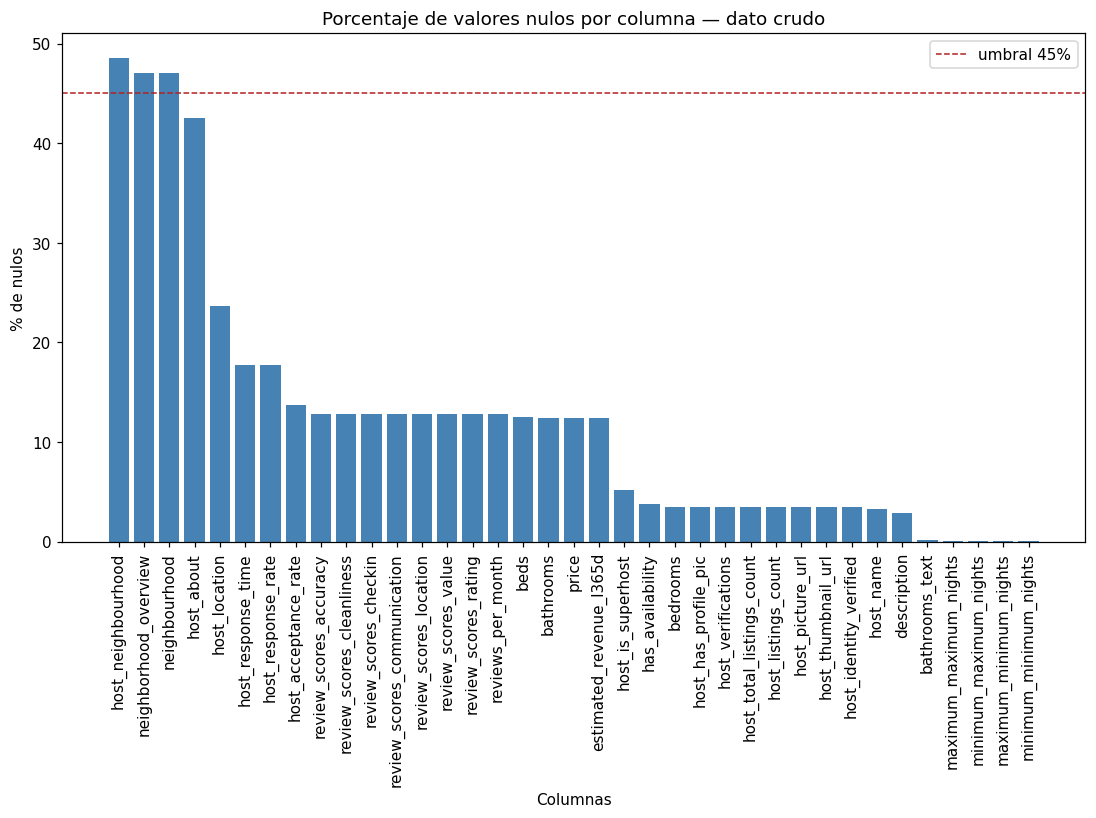

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(tabla_nulos.index, tabla_nulos["pct"], color="steelblue")
ax.set_title("Porcentaje de valores nulos por columna — dato crudo")
ax.set_xlabel("Columnas")
ax.set_ylabel("% de nulos")
ax.tick_params(axis="x", rotation=90)
ax.axhline(45, color="firebrick", linestyle="--", linewidth=1, label="umbral 45%")
ax.legend()
fig.savefig("../reports/figures/01_nulos_pct_por_columna.png", bbox_inches="tight")
plt.show()

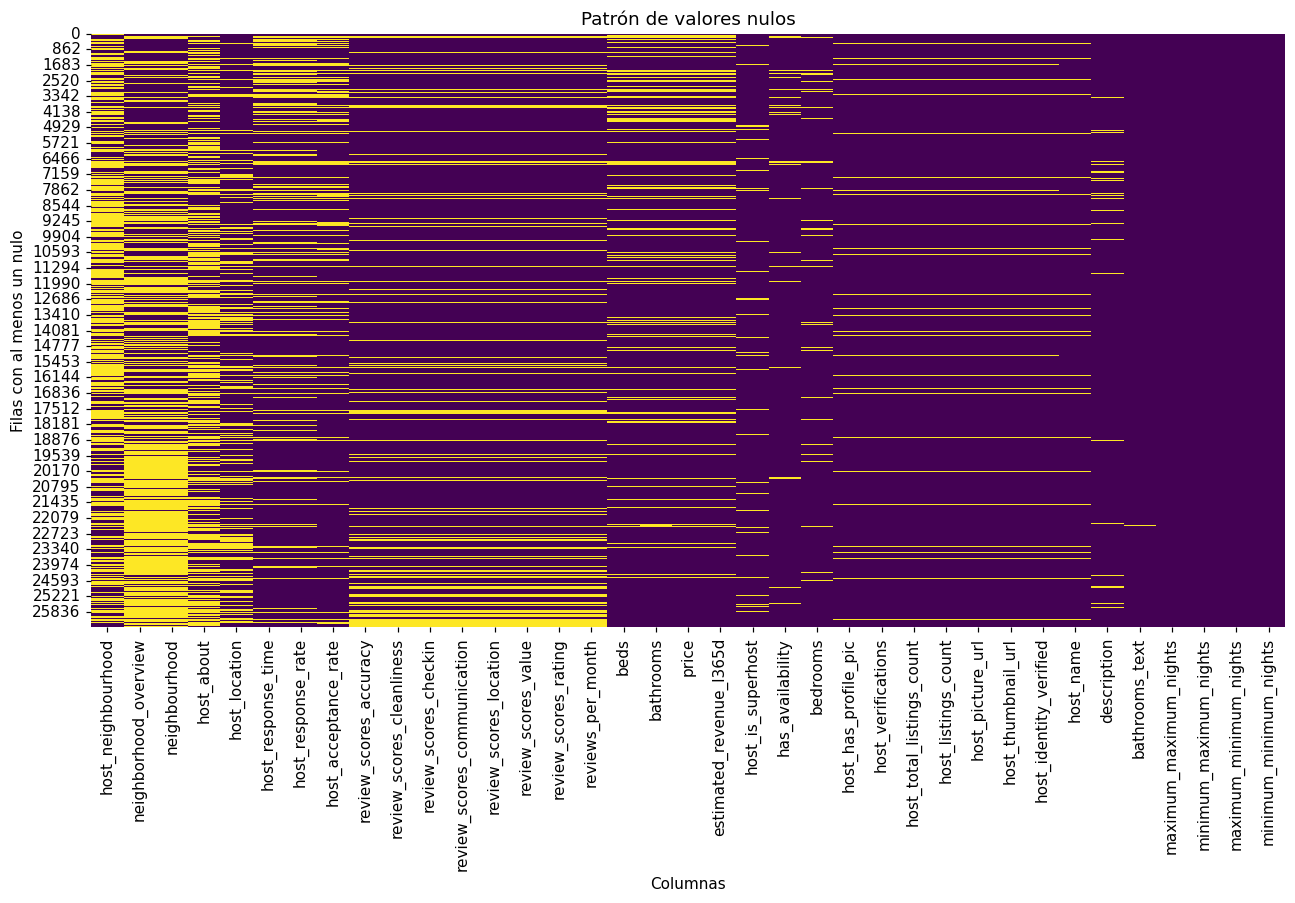

In [9]:
# Mapa de calor sobre las filas que tienen al menos un nulo: revela si los faltantes
# aparecen en bloque (patrón estructural) o dispersos (error de captura).
cols_con_nulos = tabla_nulos.index.tolist()
df_filas_nulas = df_raw.loc[df_raw[cols_con_nulos].isnull().any(axis=1), cols_con_nulos]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(df_filas_nulas.isnull(), cbar=False, cmap="viridis", ax=ax)
ax.set_title("Patrón de valores nulos")
ax.set_xlabel("Columnas")
ax.set_ylabel("Filas con al menos un nulo")
fig.savefig("../reports/figures/02_heatmap_nulos.png", bbox_inches="tight")
plt.show()

In [10]:
# Verificación del patrón: los nulos de reviews deberían concentrarse en listings sin reviews.
sin_reviews = df_raw["number_of_reviews"] == 0
cols_review = ["review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness",
               "review_scores_checkin", "review_scores_communication", "review_scores_location",
               "review_scores_value", "first_review", "last_review", "reviews_per_month"]

comparacion = pd.DataFrame({
    "pct_nulos_listings_sin_reviews": df_raw.loc[sin_reviews, cols_review].isnull().mean().mul(100).round(2),
    "pct_nulos_listings_con_reviews": df_raw.loc[~sin_reviews, cols_review].isnull().mean().mul(100).round(2),
})
print(f"Listings sin ninguna review: {sin_reviews.sum():,} ({sin_reviews.mean()*100:.1f}%)")
display(comparacion)

Listings sin ninguna review: 3,373 (12.8%)


,pct_nulos_listings_sin_reviews,pct_nulos_listings_con_reviews
review_scores_rating,100.0,0.00
review_scores_accuracy,100.0,0.01
review_scores_cleanliness,100.0,0.01
review_scores_checkin,100.0,0.01
review_scores_communication,100.0,0.01
review_scores_location,100.0,0.01
review_scores_value,100.0,0.01
first_review,0.0,0.00
last_review,0.0,0.00
reviews_per_month,100.0,0.00


### 2.3 Inconsistencias tipográficas

`neighbourhood` es texto libre capturado por el anfitrión. Para medir cuánta variación de
escritura contiene, se agruparon los valores por su forma normalizada: minúsculas, sin acentos y
sin espacios redundantes.

De **317 valores únicos crudos se pasa a 282 normalizados**, y **30 grupos reúnen más de una
grafía** de la misma zona. El caso más notorio es Cuauhtémoc, escrito de cuatro formas distintas
—con y sin acento, y una de ellas con un espacio al inicio—, o Álvaro Obregón, que aparece incluso
en mayúsculas sostenidas. Sin normalizar, cualquier agregación por zona contaría estas variantes
como barrios diferentes.

In [11]:
def normalize_text(text):
    """Forma canónica para comparar cadenas escritas por el usuario."""
    if pd.isnull(text):
        return text
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", errors="ignore").decode("utf-8")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


col_texto = "neighbourhood"
serie = df_raw[col_texto].dropna()
variantes = (
    pd.DataFrame({"crudo": serie, "normalizado": serie.map(normalize_text)})
    .drop_duplicates()
    .groupby("normalizado")["crudo"]
    .agg(list)
)
colisiones = variantes[variantes.map(len) > 1]

print(f"Valores únicos crudos:       {serie.nunique():,}")
print(f"Valores únicos normalizados: {serie.map(normalize_text).nunique():,}")
print(f"Grupos con más de una grafía: {len(colisiones)}")
for norm, formas in colisiones.head(15).items():
    print(f"  {norm!r} <- {formas}")

Valores únicos crudos:       317
Valores únicos normalizados: 282
Grupos con más de una grafía: 30
  'alcaldia cuauhtemoc, ciudad de mexico, mexico' <- ['Alcaldía Cuauhtemoc, Ciudad de México, Mexico', 'Alcaldia Cuauhtemoc, Ciudad de México, Mexico', ' Alcaldía Cuauhtémoc, Ciudad de México, Mexico', 'Alcaldía Cuauhtémoc, Ciudad de México, Mexico']
  'alcaldia tlalpan, ciudad de mexico, mexico' <- ['Alcaldia Tlalpan, Ciudad de México, Mexico', 'Alcaldía Tlalpan, Ciudad de Mexico, Mexico']
  'alvaro obregon, ciudad de mexico, mexico' <- [' Alvaro obregon, Ciudad de México, Mexico', 'Álvaro Obregón, Ciudad de México, Mexico', 'ÁLVARO OBREGÓN, CIUDAD DE MEXICO, Mexico']
  'cdmx, df, mexico' <- ['CDMX, DF, Mexico', 'CDMX, Df, Mexico']
  'centro historico, ciudad de mexico, mexico' <- ['Centro Histórico, Ciudad de México, Mexico', 'Centro Historico, Ciudad de México, Mexico']
  'centro historico, distrito federal, mexico' <- ['Centro Histórico, Distrito Federal, Mexico', 'Centro Historico, D

### 2.4 Formato del campo `price`

Antes de convertir la columna a número hay que confirmar cómo viene escrita, porque de eso depende
qué caracteres se pueden eliminar sin alterar el importe.

Los **23,127 precios no nulos siguen el formato en_US** `"$1,234.00"`: todos traen el símbolo `$`,
12,056 usan la coma como separador de miles y **todos terminan en `.00`**, es decir, el punto es el
separador decimal. **Ningún valor tiene más de un punto**, lo que descarta el formato es_MX (punto
como separador de miles) y confirma que se pueden retirar `$` y coma sin tocar el punto.

La comprobación no es un trámite: eliminar el punto junto con el `$` y la coma —como hacía la
primera versión de la limpieza— **multiplica todos los precios por 100** y convierte una tarifa de
$1,039 en $103,900.

In [12]:
muestra_price = df_raw["price"].dropna().astype(str)
print("Muestra de valores crudos:")
print(muestra_price.head(15).tolist())

# Los conteos se calculan fuera de los f-strings: hasta Python 3.11 un backslash
# dentro de las llaves de un f-string es SyntaxError, y el kernel del proyecto es 3.11.
con_simbolo  = muestra_price.str.contains("$", regex=False).sum()
con_coma     = muestra_price.str.contains(",", regex=False).sum()
con_punto    = muestra_price.str.contains(".", regex=False).sum()
con_centavos = muestra_price.str.endswith(".00").sum()

print()
print(f"Contienen '$':           {con_simbolo:,}")
print(f"Contienen ',' (miles):   {con_coma:,}")
print(f"Contienen '.' (decimal): {con_punto:,}")
print(f"Terminan en '.00':       {con_centavos:,}")

# Un valor con más de un punto indicaría formato es_MX (punto como separador de miles)
# y obligaría a invertir la lógica de limpieza.
n_puntos = muestra_price.str.count(r"\.")
multi_punto = muestra_price[n_puntos > 1]
print(f"Valores con más de un punto: {len(multi_punto):,}")
if len(multi_punto):
    print(multi_punto.head(10).tolist())


Muestra de valores crudos:
['$3,799.00', '$18,000.00', '$585.00', '$1,696.00', '$1,004.00', '$4,071.00', '$315.00', '$1,412.00', '$1,026.00', '$4,144.00', '$500.00', '$348.00', '$691.00', '$3,232.00', '$891.00']

Contienen '$':           23,127
Contienen ',' (miles):   12,056
Contienen '.' (decimal): 23,127
Terminan en '.00':       23,127
Valores con más de un punto: 0


### 2.5 Estadísticas descriptivas y distribuciones

Se revisaron las estadísticas de las variables numéricas junto con sus histogramas y los boxplots
de las columnas sobre las que después se toma una decisión de outliers.

En general las distribuciones son coherentes, con la concentración esperada en los extremos de
`availability_*`: hay alojamientos disponibles casi todo el año y otros que apenas se ofrecen unos
días. Lo que sí exige intervención son las **variables de capacidad**: con medianas de 1, los
máximos llegan a **49 baños, 50 recámaras y 50 camas**, cifras que no corresponden a un alojamiento
real. `minimum_nights` muestra el mismo patrón, con mediana de 2 noches y un máximo de 1,125.

`price` todavía no aparece en este resumen porque en el dato crudo es texto; su distribución se
analiza en la sección 3.10, ya convertida a número.

In [13]:
df_num = df_raw.select_dtypes(include=["number"])
display(df_num.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
id,26401.0,6.488522e+17,5.483558e+17,3.579700e+04,4.255992e+07,7.821415e+17,1.148084e+18,1.450438e+18
scrape_id,26401.0,2.025063e+13,0.000000e+00,2.025063e+13,2.025063e+13,2.025063e+13,2.025063e+13,2.025063e+13
host_id,26401.0,2.354112e+08,2.005844e+08,7.365000e+03,5.436477e+07,1.705833e+08,4.161560e+08,7.031773e+08
host_listings_count,25487.0,2.447000e+01,8.239000e+01,1.000000e+00,1.000000e+00,4.000000e+00,1.400000e+01,8.960000e+02
host_total_listings_count,25487.0,3.319000e+01,1.155700e+02,1.000000e+00,2.000000e+00,5.000000e+00,1.700000e+01,9.460000e+02
latitude,26401.0,1.941000e+01,4.000000e-02,1.918000e+01,1.939000e+01,1.942000e+01,1.943000e+01,1.956000e+01
longitude,26401.0,-9.917000e+01,3.000000e-02,-9.934000e+01,-9.918000e+01,-9.917000e+01,-9.915000e+01,-9.896000e+01
accommodates,26401.0,3.330000e+00,2.340000e+00,1.000000e+00,2.000000e+00,2.000000e+00,4.000000e+00,1.600000e+01
bathrooms,23120.0,1.450000e+00,1.030000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,4.900000e+01
bedrooms,25477.0,1.560000e+00,1.270000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,5.000000e+01


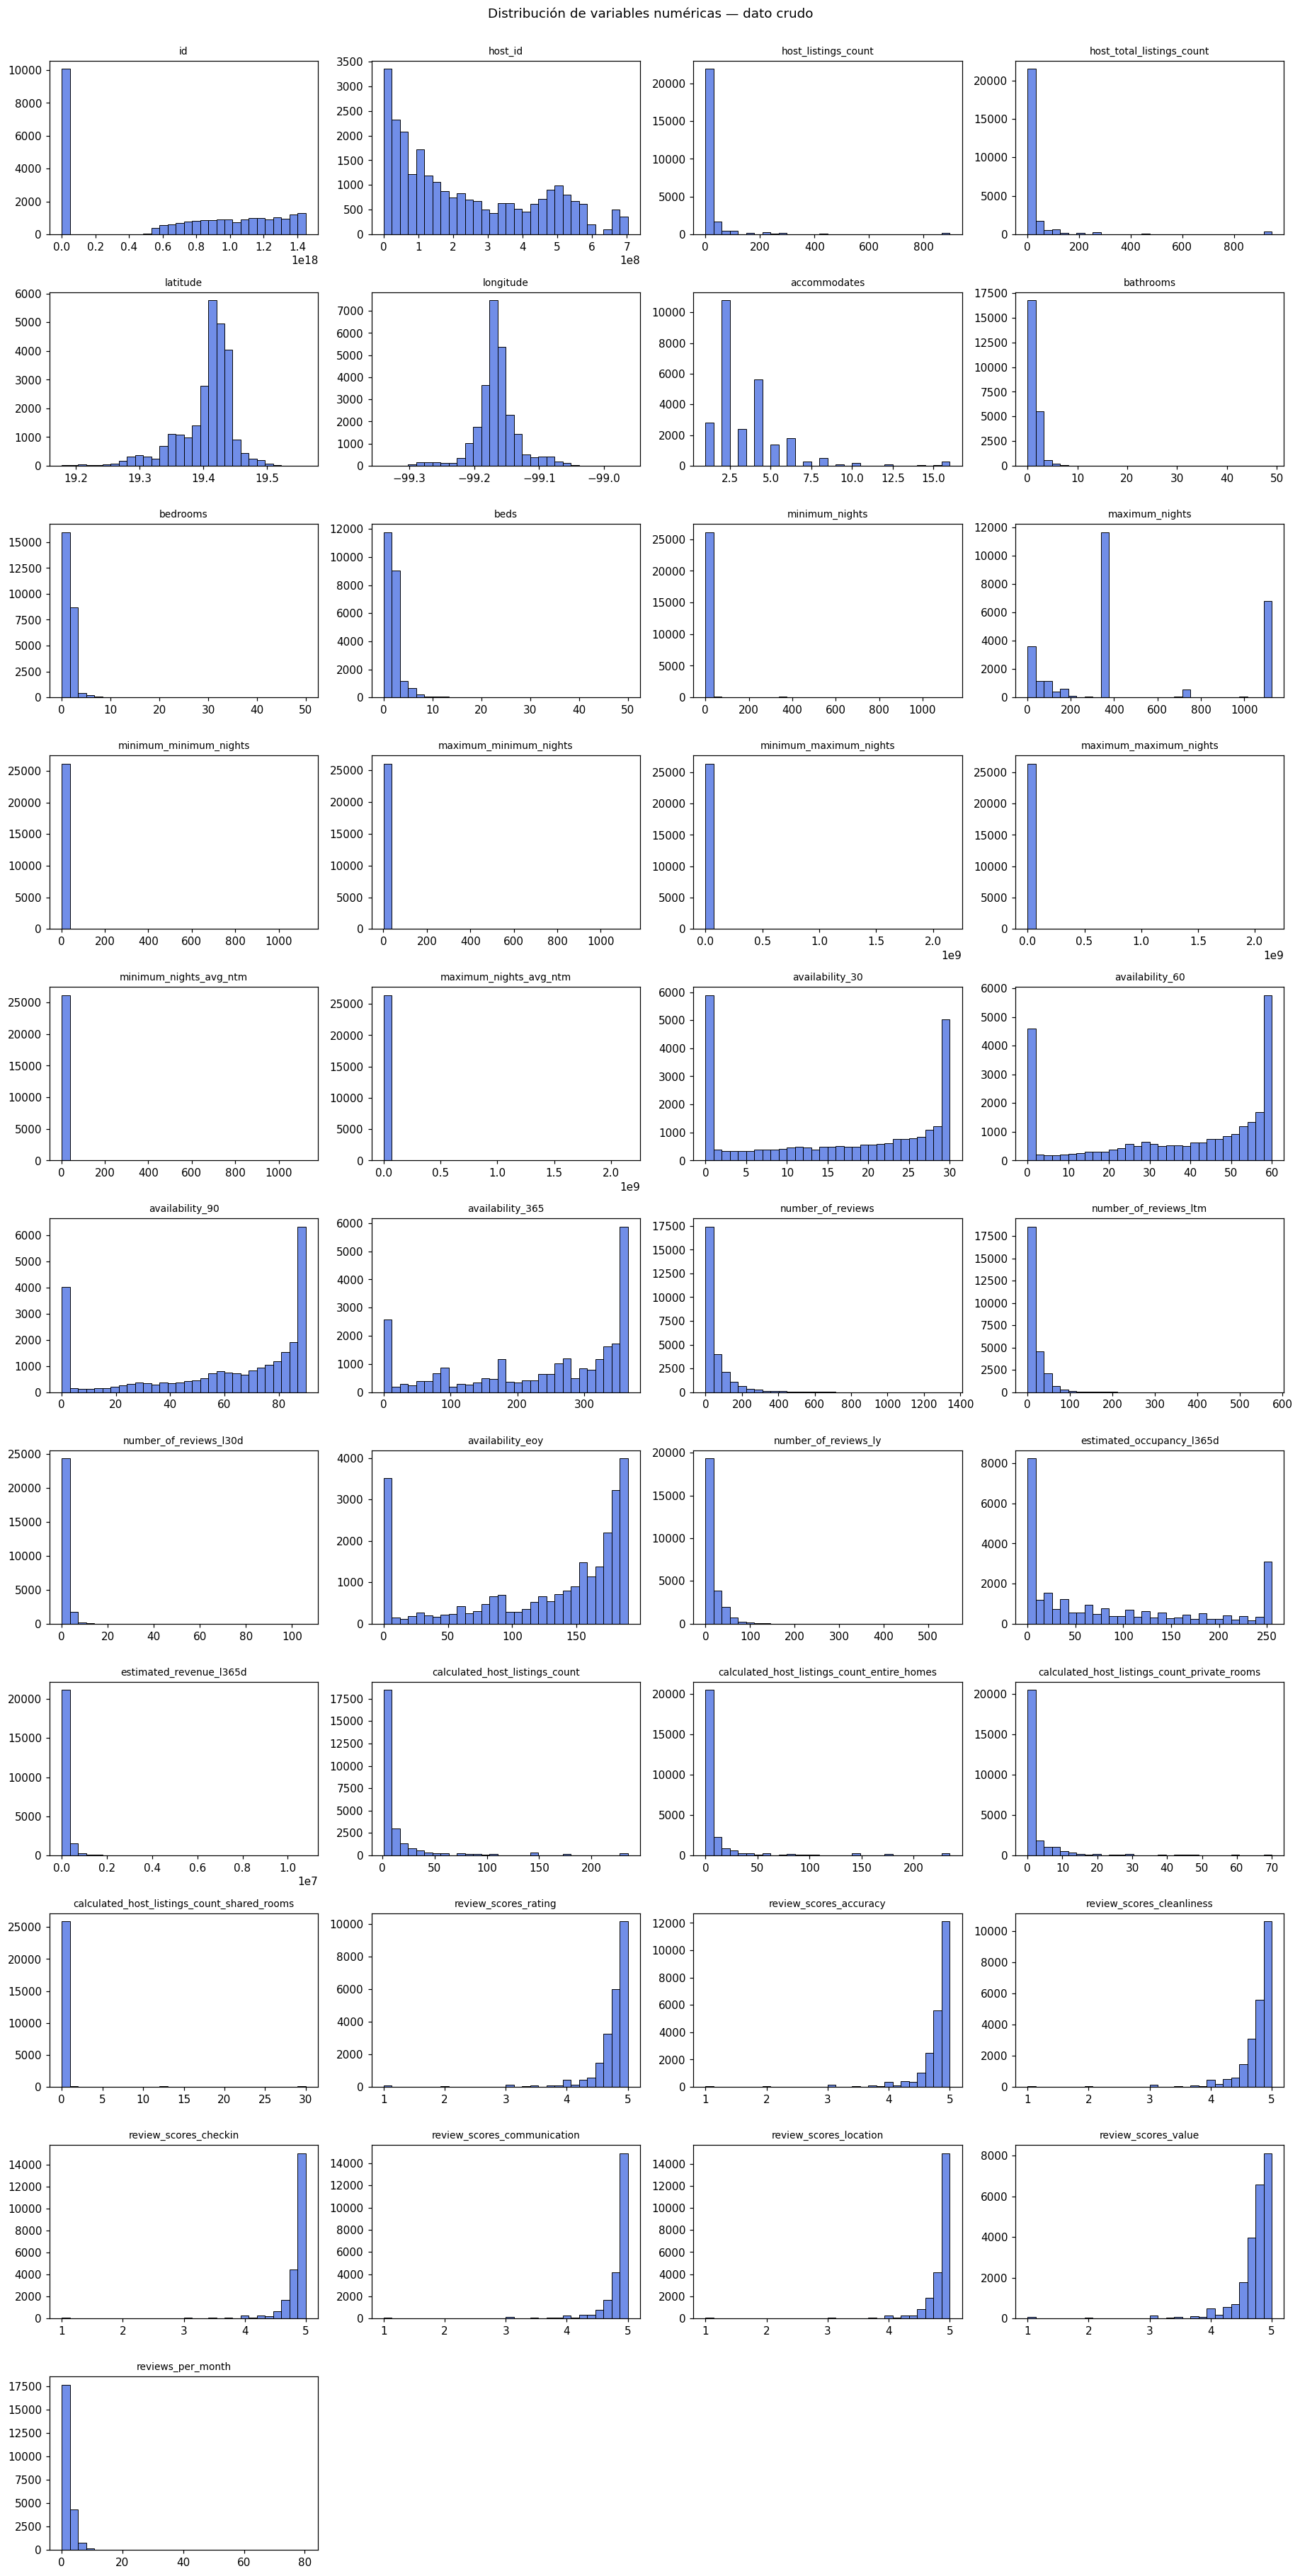

In [14]:
cols_hist = [c for c in df_num.columns if df_num[c].nunique() > 1]
n_cols = 4
n_rows = int(np.ceil(len(cols_hist) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.2, n_rows * 3.0))
for ax, col in zip(axes.ravel(), cols_hist):
    sns.histplot(df_num[col].dropna(), bins=30, color="royalblue", ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
for ax in axes.ravel()[len(cols_hist):]:
    ax.axis("off")
fig.suptitle("Distribución de variables numéricas — dato crudo", y=1.001)
fig.tight_layout()
fig.savefig("../reports/figures/03_histogramas_numericas.png", bbox_inches="tight")
plt.show()

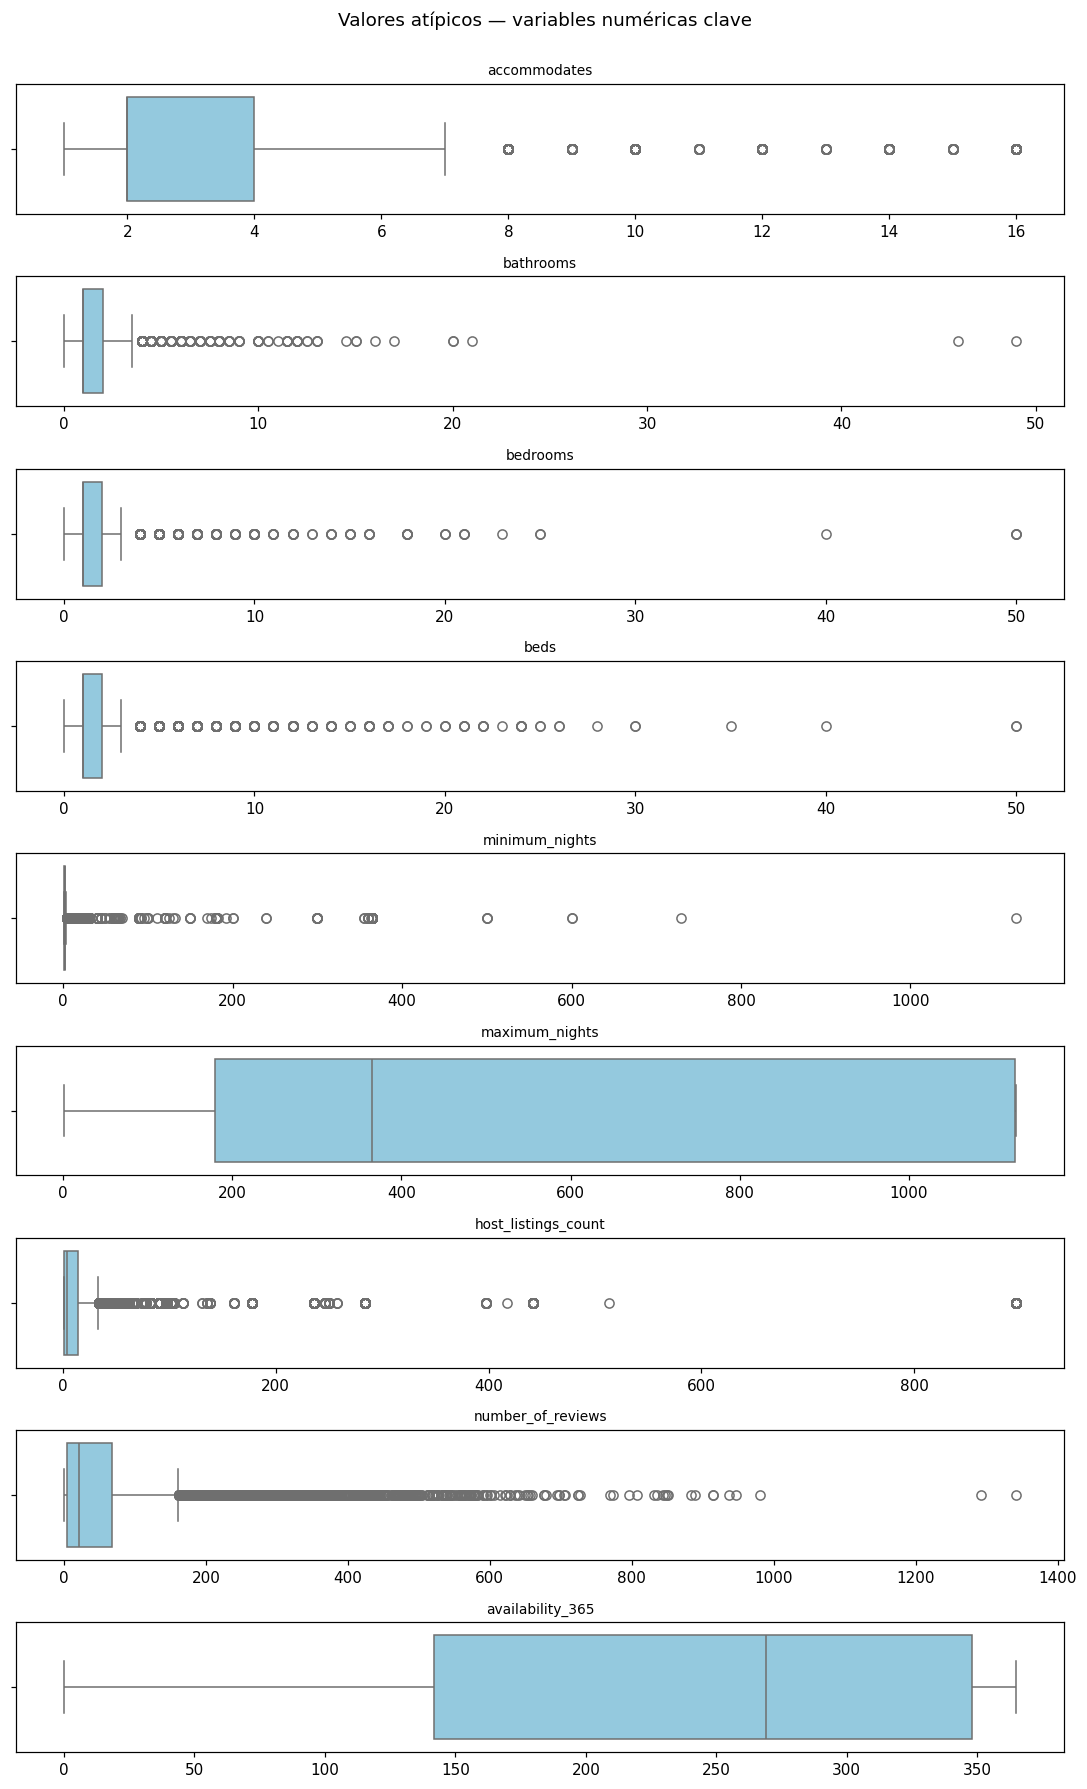

In [15]:
# Boxplots de las variables sobre las que se toma una decisión de outliers.
cols_box = ["accommodates", "bathrooms", "bedrooms", "beds",
            "minimum_nights", "maximum_nights", "host_listings_count",
            "number_of_reviews", "availability_365"]

fig, axes = plt.subplots(len(cols_box), 1, figsize=(10, 1.8 * len(cols_box)))
for ax, col in zip(axes, cols_box):
    sns.boxplot(x=df_raw[col], color="skyblue", ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
fig.suptitle("Valores atípicos — variables numéricas clave", y=1.001)
fig.tight_layout()
fig.savefig("../reports/figures/04_boxplots_numericas_crudo.png", bbox_inches="tight")
plt.show()

## 3. Transformaciones

A partir de aquí se trabaja sobre `df_silver`, una copia del dato crudo. Cada celda parte del
resultado de la anterior, y `df_raw` solo vuelve a usarse al final para comparar el antes y el
después del pipeline.

### 3.1 Deduplicación por clave de negocio

Aunque el diagnóstico no encontró duplicados, la deduplicación se deja explícita en el pipeline:
se convierten las fechas de scrape a tipo fecha, se ordena por `id` y por esas fechas, y se
conserva la última captura de cada anuncio. Si en el futuro el bronze acumula varias cargas, esta
celda se queda con la observación más reciente de cada listing —la que refleja el estado vigente de
precio, disponibilidad y reseñas— en lugar de mezclarlas.

**En esta ejecución no elimina ninguna fila** y el `assert` confirma que `id` quedó como clave
única de la tabla.

In [16]:
df_silver = df_raw.copy()

for col in ["last_scraped", "calendar_last_scraped"]:
    df_silver[col] = pd.to_datetime(df_silver[col], errors="coerce")

df_silver = (
    df_silver.sort_values(["id", "last_scraped", "calendar_last_scraped", "scrape_id"])
             .drop_duplicates(subset=["id"], keep="last")
             .reset_index(drop=True)
)

assert df_silver["id"].is_unique, "La clave de negocio sigue duplicada tras la deduplicación"

### 3.2 Corrección de `price`

Se retiran el `$` y la coma de miles **conservando el punto decimal**, según el formato confirmado
en 2.4, y el resultado se redondea a dos decimales, la escala real de una tarifa monetaria.

La conversión no perdió información: **los 3,274 nulos de entrada siguen siendo 3,274 y no hubo un
solo valor no convertible**. El precio mediano queda en **$1,039 MXN por noche**, con un máximo de
$900,000 que se trata en la sección 3.10.

La segunda celda valida el importe contra otra fuente del mismo dato: el ingreso estimado del
último año dividido entre las noches ocupadas debe aproximar el precio por noche. En los **18,391
registros comparables el ratio es exactamente 1.000**, lo que confirma que el precio quedó en la
escala correcta. Con el punto decimal borrado, ese mismo ratio rondaría 100.

In [17]:
serie_price = df_silver["price"].astype("string").str.strip()
nulos_antes = serie_price.isna().sum()

# Se retiran el símbolo '$' y la coma de miles; el punto decimal se conserva.
serie_price = (serie_price
               .str.replace("$", "", regex=False)
               .str.replace(",", "", regex=False))

df_silver["price"] = pd.to_numeric(serie_price, errors="coerce").round(2)
nulos_despues = df_silver["price"].isna().sum()

print(f"Nulos antes: {nulos_antes:,} | después: {nulos_despues:,} | no convertibles: {nulos_despues - nulos_antes:,}")
display(df_silver["price"].describe().round(2))

Nulos antes: 3,274 | después: 3,274 | no convertibles: 0


count     23127.0
mean      1989.29
std      18500.68
min          66.0
25%         630.0
50%        1039.0
75%        1647.0
max      900000.0
Name: price, dtype: Float64

In [18]:
# Validación cruzada del importe: el ingreso estimado del último año debe aproximar
# price * noches ocupadas. Con el bug anterior (punto decimal eliminado) este ratio
# daba ~100; corregido debe rondar 1.
val = df_silver[(df_silver["estimated_occupancy_l365d"] > 0) & (df_silver["price"] > 0)].copy()
val["price_implicito"] = val["estimated_revenue_l365d"] / val["estimated_occupancy_l365d"]
val["ratio"] = (val["price_implicito"] / val["price"]).round(3)

print(f"Registros validables: {len(val):,}")
print(f"Ratio mediano price_implicito/price: {val['ratio'].median():.3f}  (esperado ~1.0)")
display(val["ratio"].describe().round(3))

Registros validables: 18,391
Ratio mediano price_implicito/price: 1.000  (esperado ~1.0)


count    18391.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: ratio, dtype: Float64

### 3.3 Tasas con símbolo `%`

`host_response_rate` y `host_acceptance_rate` llegan como texto (`"100%"`), formato que impide
promediarlas, compararlas o correlacionarlas. Se elimina el símbolo y se convierten a numérico.

Ya convertidas, la **tasa de respuesta promedia 94.2 y la de aceptación 88.9**, ambas con mediana
en 100: la mayoría de los anfitriones responde y acepta casi todas las solicitudes, y la dispersión
proviene de una minoría con tasas muy bajas. Sus nulos (4,686 y 3,610) **no se imputan**, porque
significan que el anfitrión todavía no tiene historial.

In [19]:
cols_rate = ["host_response_rate", "host_acceptance_rate"]
for col in cols_rate:
    df_silver[col] = pd.to_numeric(
        df_silver[col].astype("string").str.replace("%", "", regex=False),
        errors="coerce",
    )
display(df_silver[cols_rate].describe().round(2))

,host_response_rate,host_acceptance_rate
count,21715.0,22791.0
mean,94.2,88.85
std,19.59,24.77
min,0.0,0.0
25%,100.0,94.0
50%,100.0,99.0
75%,100.0,100.0
max,100.0,100.0


### 3.4 Categorización de `host_response_time`

Las cuatro categorías originales se agrupan en tres niveles de servicio: `within an hour` y
`within a few hours` pasan a **Fast**, `within a day` a **Moderate** y `a few days or more` a
**Slow**. La columna original se conserva hasta el subset final para poder auditar el mapeo.

El resultado muestra un mercado que responde rápido: **19,743 anuncios quedan en Fast**, frente a
1,060 en Moderate y 912 en Slow. Los **4,686 nulos** corresponden a anfitriones sin historial de
respuesta y se mantienen como tales.

In [20]:
response_time_map = {
    "within an hour": "Fast",
    "within a few hours": "Fast",
    "within a day": "Moderate",
    "a few days or more": "Slow",
}

df_silver["host_response_category"] = df_silver["host_response_time"].map(response_time_map)
display(df_silver["host_response_category"].value_counts(dropna=False))

host_response_category
Fast        19743
NaN          4686
Moderate     1060
Slow          912
Name: count, dtype: int64

### 3.5 Binarias de `host_verifications`

La columna guarda una lista escrita como texto (`"['email', 'phone']"`). Se parsea con
`ast.literal_eval` y se generan indicadores binarios con `explode` + `get_dummies`, alineados por
índice contra `df_silver` para no perder las transformaciones previas.

En todo el dataset existen **solo tres métodos de verificación** —`email`, `phone` y `work_email`—,
así que la columna se resume en tres binarias: `verif_email`, `verif_phone` y `verif_work_email`.

In [21]:
def parse_list(value):
    """Convierte la representación textual de lista a lista de Python; tolera nulos y basura."""
    if isinstance(value, list):
        return value
    if pd.isnull(value):
        return []
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []


verifs = df_silver["host_verifications"].apply(parse_list)

metodos = sorted({m for lista in verifs for m in lista})
print("Métodos de verificación encontrados:", metodos)

dummies = (
    pd.get_dummies(verifs.explode().dropna())
    .groupby(level=0).max()
    .reindex(df_silver.index, fill_value=0)
    .astype("int8")
)
dummies.columns = [f"verif_{re.sub(r'[^a-z0-9]+', '_', str(c).lower()).strip('_')}" for c in dummies.columns]

df_silver = pd.concat([df_silver, dummies], axis=1)

Métodos de verificación encontrados: ['email', 'phone', 'work_email']


### 3.6 Amenities: top-10 e indicador de equipamiento

Igual que `host_verifications`, `amenities` es una lista guardada como texto. Se parsea, se
normaliza cada servicio a minúsculas y se cuentan las frecuencias para quedarse con los diez más
comunes como columnas binarias, además de un conteo total de servicios por anuncio.

Se encontraron **6,513 amenities distintos**, una cola muy larga en la que la mayoría aparece un
puñado de veces. El top 10 lo encabezan **wifi (23,052 anuncios) y kitchen (22,868)**, seguidos de
hot water, hangers, essentials, dishes and silverware, iron, cooking basics, dedicated workspace y
bed linens: son prácticamente el estándar mínimo del mercado, más útiles como línea base que como
diferenciador. El conteo total, `amenities_count`, tiene **mediana de 32 servicios** y llega hasta
102.

In [22]:
amenities = df_silver["amenities"].apply(parse_list).apply(
    lambda lista: [str(a).strip().lower() for a in lista if str(a).strip()]
)

frecuencias = Counter(a for lista in amenities for a in lista)
top_amenities = [a for a, _ in frecuencias.most_common(10)]

print(f"Amenities únicos: {len(frecuencias):,}")
display(pd.DataFrame(frecuencias.most_common(10), columns=["amenity", "frecuencia"]))

Amenities únicos: 6,513


,amenity,frecuencia
0,wifi,23052
1,kitchen,22868
2,hot water,21404
3,hangers,20034
4,essentials,19737
5,dishes and silverware,19182
6,iron,19105
7,cooking basics,19072
8,dedicated workspace,17682
9,bed linens,17570


In [23]:
sets_amenities = amenities.map(set)
for amenity in top_amenities:
    col = "amen_" + re.sub(r"[^a-z0-9]+", "_", amenity).strip("_")
    df_silver[col] = sets_amenities.map(lambda s, a=amenity: int(a in s)).astype("int8")

# Conteo sobre la lista parseada: partir el string por coma inflaba el valor
# en amenities cuyo nombre contiene comas.
df_silver["amenities_count"] = amenities.map(len).astype("int16")

display(df_silver["amenities_count"].describe().round(2))

count    26401.00
mean        31.61
std         15.63
min          0.00
25%         20.00
50%         32.00
75%         43.00
max        102.00
Name: amenities_count, dtype: float64

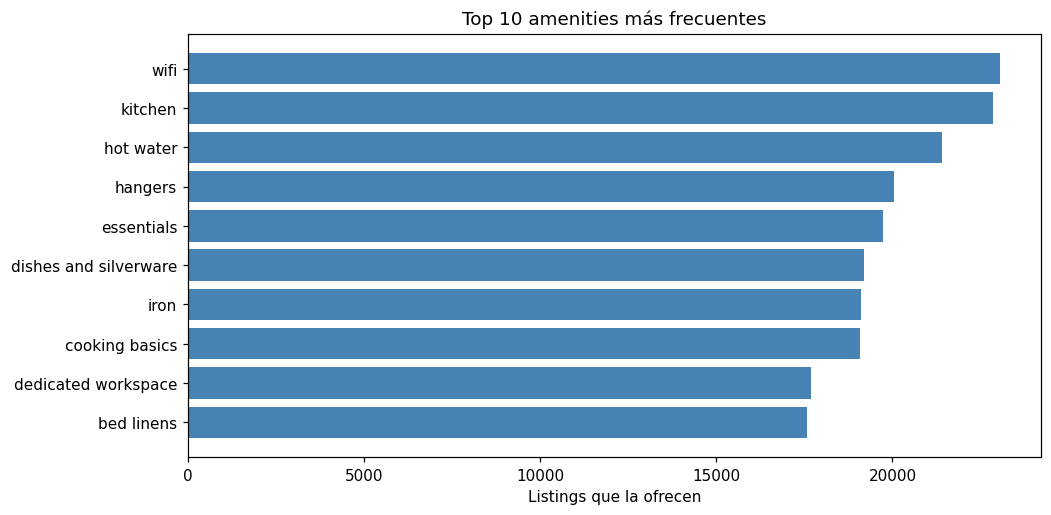

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
top_df = pd.DataFrame(frecuencias.most_common(10), columns=["amenity", "frecuencia"])
ax.barh(top_df["amenity"][::-1], top_df["frecuencia"][::-1], color="steelblue")
ax.set_title("Top 10 amenities más frecuentes")
ax.set_xlabel("Listings que la ofrecen")
fig.savefig("../reports/figures/05_top_amenities.png", bbox_inches="tight")
plt.show()

### 3.7 Normalización de `bathrooms` y de texto

`bathrooms` se redondea hacia arriba: un registro con 5.5 baños corresponde a cinco completos más
un medio baño, que sigue siendo una unidad sanitaria utilizable. `neighbourhood` se normaliza con
la misma función usada en el diagnóstico y **se conserva**: eliminarla dejaría el análisis
geográfico sin la llave escrita por el anfitrión.

Tras el redondeo los baños quedan en enteros, y ahí se ve el problema que atiende la sección 3.10:
junto a los valores razonables aparecen registros con **21, 46 y hasta 49 baños**. Los barrios, por
su parte, bajan de 317 grafías a **282 valores normalizados**.

In [25]:
df_silver["bathrooms"] = np.ceil(df_silver["bathrooms"]).astype("Int64")
df_silver["neighbourhood"] = df_silver["neighbourhood"].map(normalize_text)

print("Baños (valores únicos):", sorted(df_silver["bathrooms"].dropna().unique().tolist()))
print("Barrios únicos tras normalizar:", df_silver["neighbourhood"].nunique())

Baños (valores únicos): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 20, 21, 46, 49]
Barrios únicos tras normalizar: 282


### 3.8 Tipado de banderas booleanas

El origen es Mongo, así que estos campos pueden llegar como `True`/`False` o como los `t`/`f` del
CSV nativo de InsideAirbnb; el mapeo cubre ambos formatos y el resultado queda en tipo `boolean` de
pandas, que admite nulos.

El conteo deja ver la composición del mercado: **9,677 superhosts frente a 15,365 que no lo son**,
24,939 anfitriones con foto de perfil, 24,355 con identidad verificada y **10,704 anuncios con
reserva instantánea** contra 15,697 que exigen aprobación previa.

In [26]:
cols_bool = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified",
             "has_availability", "instant_bookable"]

mapa_bool = {"t": True, "f": False, "true": True, "false": False, "1": True, "0": False}
for col in cols_bool:
    df_silver[col] = (df_silver[col].astype("string").str.strip().str.lower()
                      .map(mapa_bool).astype("boolean"))

display(df_silver[cols_bool].apply(lambda s: s.value_counts(dropna=False)).T)

,False,True,<NA>
host_is_superhost,15365,9677,1359
host_has_profile_pic,548,24939,914
host_identity_verified,1132,24355,914
has_availability,<NA>,25401,1000
instant_bookable,15697,10704,0


### 3.9 Imputación

Solo se imputa donde el faltante tiene un valor conocido por regla de negocio: un listing sin
ninguna review tiene una tasa de **0 reviews por mes**, no un dato desconocido. Con ese criterio se
llenaron **3,373 registros** de `reviews_per_month`.

Las demás métricas de reseñas —`review_scores_*`, `first_review` y `last_review`— **no se imputan**:
rellenarlas con la media inventaría calificaciones que el anuncio nunca recibió y sesgaría
cualquier análisis o modelo posterior. El mismo criterio aplica a `host_response_rate` y
`host_acceptance_rate`, donde el nulo indica ausencia de historial.

In [27]:
sin_reviews = df_silver["number_of_reviews"] == 0
imputados = (df_silver.loc[sin_reviews, "reviews_per_month"].isna()).sum()
df_silver.loc[sin_reviews, "reviews_per_month"] = df_silver.loc[sin_reviews, "reviews_per_month"].fillna(0)

### 3.10 Tratamiento de outliers

El boxplot y los percentiles de `price` muestran la magnitud del problema: la mediana está en
**$1,039** y el percentil 99 en $10,000, pero el 99.9 salta a $59,221 y el máximo llega a **$900,000
por noche**. No es un error de conversión —la validación cruzada de 3.2 lo descarta—, sino un puñado
de anuncios con un precio imposible.

Se descartan únicamente los valores que no admiten lectura de negocio: precios fuera del rango
**[1, 100,000] MXN** y alojamientos con más de **15** baños, recámaras o camas. El recorte elimina
**16 filas por precio y 56 por capacidad**, apenas un 0.3% del dataset. Los precios altos de
propiedades de lujo, los anfitriones con cientos de anuncios y las estancias mínimas largas se
conservan: son variación real del mercado, no errores de captura.

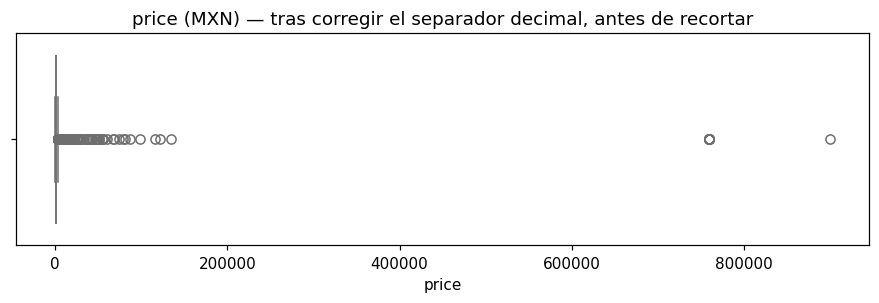

0.500      1039.0
0.900      2730.4
0.990     10000.0
0.999    59221.16
1.000    900000.0
Name: price, dtype: Float64

In [28]:
fig, ax = plt.subplots(figsize=(10, 2.5))
sns.boxplot(x=df_silver["price"], color="skyblue", ax=ax)
ax.set_title("price (MXN) — tras corregir el separador decimal, antes de recortar")
fig.savefig("../reports/figures/06_boxplot_price_pre_recorte.png", bbox_inches="tight")
plt.show()

display(df_silver["price"].quantile([0.5, 0.9, 0.99, 0.999, 1.0]).round(2))

In [29]:
# Rango válido de price: entre 1 y 100,000 MXN por noche. bathrooms / bedrooms / beds: hasta 15.
fuera_rango = (df_silver["price"] < 1) | (df_silver["price"] > 100000)
print(f"Precios fuera de [1, 100,000] MXN: {fuera_rango.sum():,}")
df_silver = df_silver[~fuera_rango | df_silver["price"].isna()].copy()

excede = (df_silver[["bathrooms", "bedrooms", "beds"]] > 15).any(axis=1)
print(f"Con bathrooms / bedrooms / beds > 15: {excede.sum():,}")
df_silver = df_silver[~excede].copy().reset_index(drop=True)

Precios fuera de [1, 100,000] MXN: 16
Con bathrooms / bedrooms / beds > 15: 56


## 4. Subset curado

Se seleccionan las columnas con valor analítico y se descartan las que no lo tienen: identificadores
del scrape, URLs, imágenes, texto libre largo y las derivadas redundantes de `minimum_nights` /
`maximum_nights`.

**Se conservan 57 columnas y se descartan 35.** Las dos cifras suman más que las 77 originales
porque en el camino se agregaron las binarias de verificaciones y amenities, el conteo de servicios
y la categoría de tiempo de respuesta. Entre las descartadas están `_id`, `listing_url`,
`picture_url`, `host_about`, `neighborhood_overview`, `host_neighbourhood` y las seis variantes de
`minimum_*` / `maximum_*` que no aportan nada sobre las dos columnas base.

In [30]:
COLUMNAS_SILVER = [
    # Identificación
    "id", "name", "host_id",
    # Anfitrión
    "host_since", "host_is_superhost", "host_identity_verified",
    "host_response_category", "host_response_rate", "host_acceptance_rate",
    "host_listings_count", "verif_email", "verif_phone", "verif_work_email",
    # Ubicación
    "neighbourhood", "neighbourhood_cleansed", "latitude", "longitude",
    # Propiedad
    "property_type", "room_type", "accommodates", "bathrooms", "bedrooms", "beds",
    "amenities_count",
    # Precio y estancia
    "price", "minimum_nights", "maximum_nights",
    # Disponibilidad
    "has_availability", "availability_30", "availability_90", "availability_365",
    "instant_bookable",
    # Demanda y reputación
    "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "first_review", "last_review",
    "review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness",
    "review_scores_checkin", "review_scores_communication", "review_scores_location",
    "review_scores_value",
    "estimated_occupancy_l365d", "estimated_revenue_l365d",
    # Trazabilidad del scrape que originó la fila
    "last_scraped",
]
COLUMNAS_SILVER += sorted(c for c in df_silver.columns if c.startswith("amen_"))

descartadas = [c for c in df_silver.columns if c not in COLUMNAS_SILVER]
print(f"Se conservan {len(COLUMNAS_SILVER)} columnas y se descartan {len(descartadas)}:")
print(descartadas)

df_silver = df_silver[COLUMNAS_SILVER].copy()

Se conservan 57 columnas y se descartan 35:
['_id', 'listing_url', 'scrape_id', 'source', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 'host_name', 'host_location', 'host_about', 'host_response_time', 'host_thumbnail_url', 'host_picture_url', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'bathrooms_text', 'amenities', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_60', 'calendar_last_scraped', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'host_neighbourhood']


## 5. Validaciones de salida

Cuatro comprobaciones cierran el pipeline antes de escribir el archivo: que `id` sea único, que
todos los precios caigan dentro del rango declarado, que no quede ninguna columna con listas de
Python sin serializar —romperían el CSV al releerlo— y que ningún listing sin reseñas conserve un
nulo en `reviews_per_month`.

**Las cuatro pasan.** La tabla de tipos confirma además que cada columna quedó con el suyo: fechas
como `datetime`, banderas como `boolean`, y precio y tasas como numéricos.

In [31]:
assert df_silver["id"].is_unique, "Hay listings duplicados en la salida"
assert df_silver["price"].dropna().between(1, 100000).all(), "Precios fuera de rango"
assert not any(df_silver[c].dtype == "object" and df_silver[c].map(type).eq(list).any()
               for c in df_silver.columns), "Quedan columnas con listas de Python sin serializar"
assert df_silver.loc[df_silver["number_of_reviews"] == 0, "reviews_per_month"].notna().all(), \
    "Quedan nulos en reviews_per_month para listings sin reviews"

print("Validaciones OK")
display(df_silver.dtypes.rename("dtype").to_frame())
df_silver.head()

Validaciones OK


,dtype
id,int64
name,object
host_id,int64
host_since,object
host_is_superhost,boolean
host_identity_verified,boolean
host_response_category,object
host_response_rate,Int64
host_acceptance_rate,Int64
host_listings_count,float64


,id,name,host_id,host_since,host_is_superhost,host_identity_verified,host_response_category,host_response_rate,host_acceptance_rate,host_listings_count,verif_email,verif_phone,verif_work_email,neighbourhood,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities_count,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_90,availability_365,instant_bookable,number_of_reviews,number_of_reviews_ltm,reviews_per_month,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,estimated_occupancy_l365d,estimated_revenue_l365d,last_scraped,amen_bed_linens,amen_cooking_basics,amen_dedicated_workspace,amen_dishes_and_silverware,amen_essentials,amen_hangers,amen_hot_water,amen_iron,amen_kitchen,amen_wifi
0,35797,Villa Dante,153786,2010-06-28,False,True,NaN,<NA>,<NA>,1.0,1,1,1,"mexico city, d.f., mexico",Cuajimalpa de Morelos,19.38283,-99.27178,Entire villa,Entire home/apt,2,1,1.0,1.0,12,3799.0,1,7,True,29,89,364,False,0,0,0.00,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,2025-06-26,1,0,0,0,0,0,1,0,1,1
1,44616,Condesa Haus,196253,2010-08-09,False,True,Fast,100,91,13.0,1,1,1,NaN,Cuauhtémoc,19.41162,-99.17794,Entire home,Entire home/apt,14,6,5.0,8.0,26,18000.0,1,180,True,29,89,360,False,65,1,0.39,2011-11-09,2025-01-01,4.59,4.56,4.70,4.87,4.78,4.98,4.47,6,108000.0,2025-07-01,0,1,0,1,1,1,0,1,1,1
2,56074,Great space in historical San Rafael,265650,2010-10-19,False,True,Fast,100,100,1.0,1,1,0,"mexico city, df, mexico",Cuauhtémoc,19.43977,-99.15605,Entire condo,Entire home/apt,2,1,1.0,1.0,28,585.0,15,250,True,3,63,338,False,84,1,0.48,2011-04-02,2025-02-27,4.87,4.95,4.88,4.98,4.94,4.76,4.79,30,17550.0,2025-07-01,1,1,0,1,1,1,1,1,1,1
3,67703,"2 bedroom apt. deco bldg, Condesa",334451,2011-01-04,False,True,Fast,100,47,3.0,1,1,0,NaN,Cuauhtémoc,19.41152,-99.16857,Entire rental unit,Entire home/apt,4,1,2.0,2.0,21,1696.0,2,30,True,3,32,267,False,50,1,0.30,2011-11-17,2024-10-30,4.90,4.82,4.76,4.94,4.92,4.98,4.92,6,10176.0,2025-07-01,1,0,1,1,1,1,1,1,1,1
4,70644,Beautiful light Studio Coyoacan- full equipped !,212109,2010-08-24,True,True,Fast,100,85,3.0,1,1,1,"mexico city, federal district, mexico",Coyoacán,19.35448,-99.16217,Entire rental unit,Entire home/apt,2,1,1.0,1.0,50,1004.0,3,180,True,10,25,211,False,132,8,0.81,2012-02-14,2024-12-28,4.92,4.91,4.96,4.96,4.98,4.96,4.92,48,48192.0,2025-07-01,1,1,1,1,1,1,1,1,1,1


## 6. Gráficas derivadas de las transformaciones

Las figuras de esta sección solo son posibles después de la limpieza, porque antes `price` era
texto y las categorías de respuesta no existían.

Ya recortado, el precio se distribuye de forma **fuertemente asimétrica**: en escala logarítmica se
ve una sola concentración alrededor de los $1,000, sin la cola que aplastaba el boxplot original.
Por tipo de alojamiento el orden es el esperado: **Entire home/apt domina en volumen** (17,199
anuncios) con una mediana de **$1,275**, seguido de Private room ($562) y Shared room ($252);
Hotel room es marginal en número —81 anuncios— pero el más caro por noche ($1,693).

El mapa de correlación no muestra ninguna relación fuerte con el precio: las mayores son
`accommodates` y `bedrooms` (0.39) y `bathrooms` (0.36), mientras que el equipamiento
(`amenities_count`, 0.13) y la reputación (`review_scores_rating`, 0.04) apenas influyen. Entre sí,
las variables de capacidad sí están muy correlacionadas —`accommodates` con `beds`, 0.84—, algo a
tener en cuenta si más adelante se modela con todas ellas.

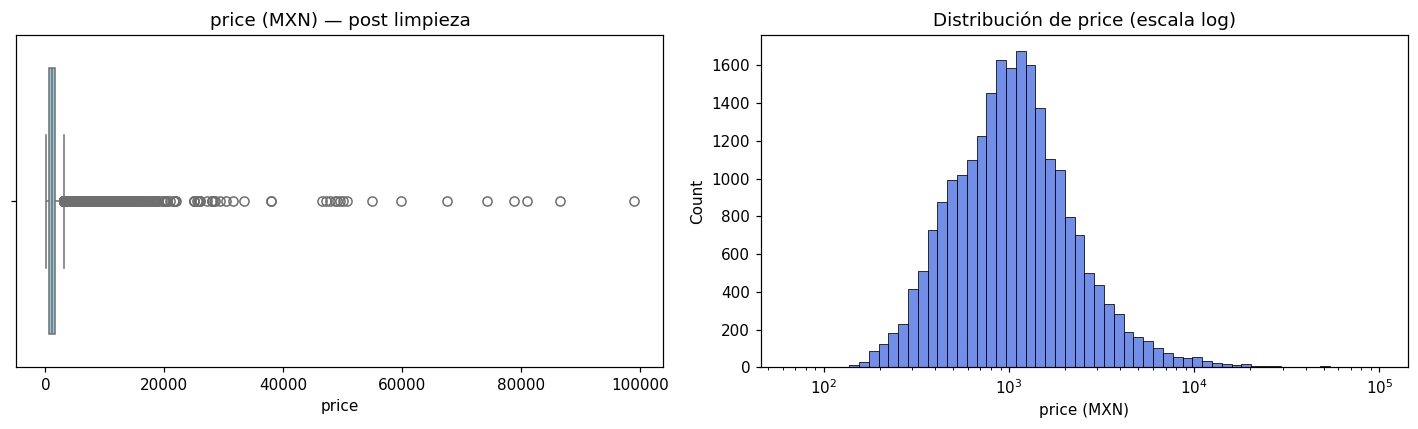

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x=df_silver["price"], color="skyblue", ax=axes[0])
axes[0].set_title("price (MXN) — post limpieza")
sns.histplot(df_silver["price"].dropna(), bins=60, log_scale=(True, False),
             color="royalblue", ax=axes[1])
axes[1].set_title("Distribución de price (escala log)")
axes[1].set_xlabel("price (MXN)")
fig.tight_layout()
fig.savefig("../reports/figures/07_price_post_limpieza.png", bbox_inches="tight")
plt.show()

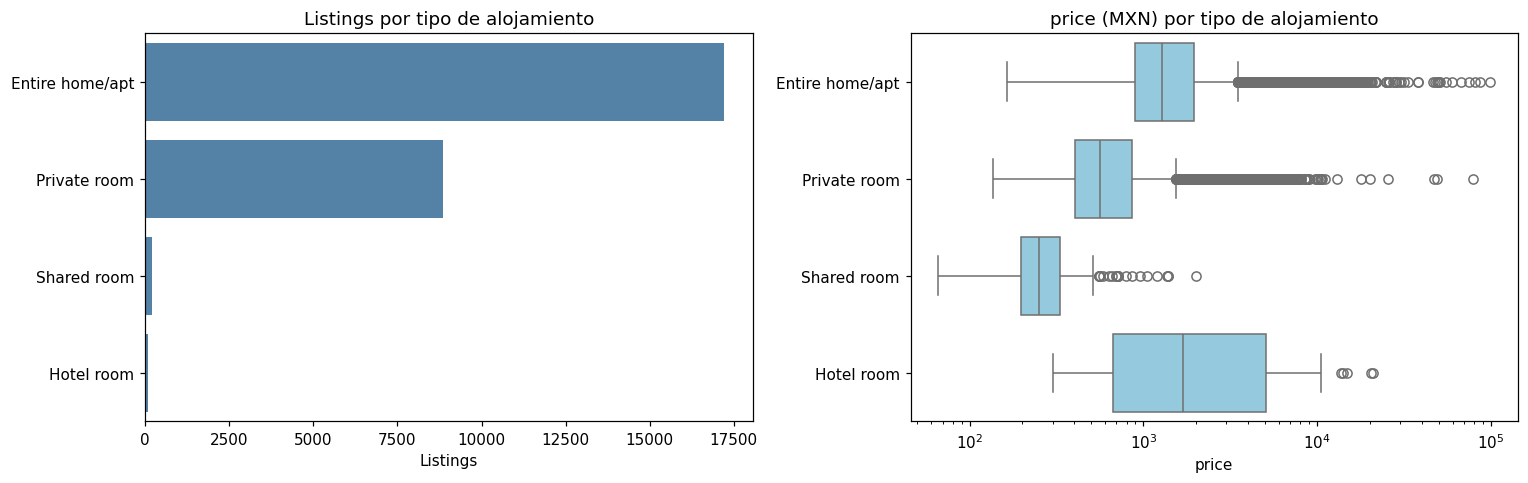

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
orden = df_silver["room_type"].value_counts().index
sns.countplot(data=df_silver, y="room_type", order=orden, color="steelblue", ax=axes[0])
axes[0].set_title("Listings por tipo de alojamiento")
axes[0].set_xlabel("Listings")
axes[0].set_ylabel("")

sns.boxplot(data=df_silver[df_silver["price"].notna()], x="price", y="room_type",
            order=orden, color="skyblue", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("price (MXN) por tipo de alojamiento")
axes[1].set_ylabel("")
fig.tight_layout()
fig.savefig("../reports/figures/08_price_por_room_type.png", bbox_inches="tight")
plt.show()

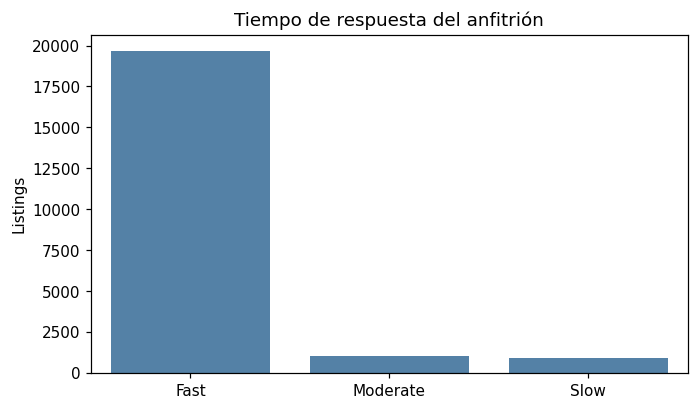

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df_silver, x="host_response_category",
              order=["Fast", "Moderate", "Slow"], color="steelblue", ax=ax)
ax.set_title("Tiempo de respuesta del anfitrión")
ax.set_xlabel("")
ax.set_ylabel("Listings")
fig.savefig("../reports/figures/09_host_response_category.png", bbox_inches="tight")
plt.show()

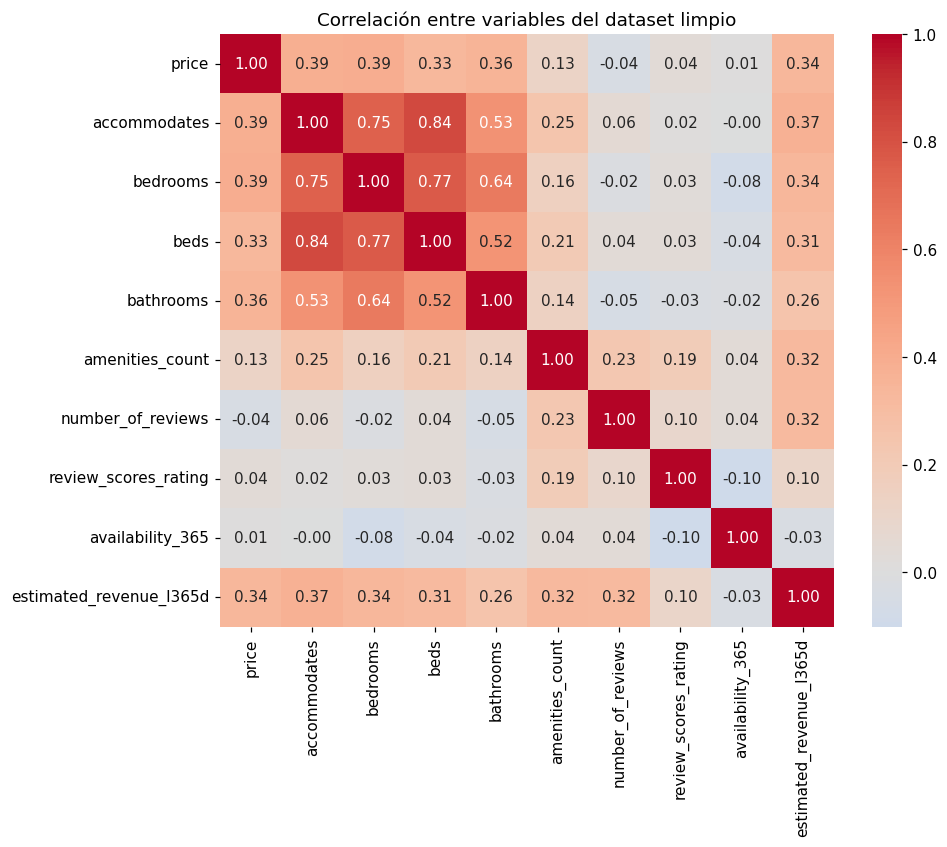

In [35]:
cols_corr = ["price", "accommodates", "bedrooms", "beds", "bathrooms",
             "amenities_count", "number_of_reviews", "review_scores_rating",
             "availability_365", "estimated_revenue_l365d"]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df_silver[cols_corr].corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre variables del dataset limpio")
fig.savefig("../reports/figures/10_correlacion.png", bbox_inches="tight")
plt.show()

## 7. Persistencia — capa silver

Se escribe la tabla curada en `data/silver/listings.csv` y se vuelve a leer para comprobar que el
archivo en disco tiene exactamente la misma forma que el DataFrame en memoria.

El pipeline completo pasa de **26,401 filas y 77 columnas a 26,329 filas y 57 columnas**: se perdió
el 0.3% de los registros —solo los imposibles de negocio— y el ancho quedó reducido a las columnas
con valor analítico más las binarias generadas. Las diez figuras del diagnóstico quedan exportadas
en `reports/figures`.

In [37]:
df_silver.to_csv("../data/silver/listings.csv", index=False, encoding="utf-8")

verif = pd.read_csv("../data/silver/listings.csv", low_memory=False)
assert verif.shape == df_silver.shape, f"Relectura inconsistente: {verif.shape} vs {df_silver.shape}"

print("Archivo escrito: ../data/silver/listings.csv")
print(f"Reducción total: {len(df_raw):,} -> {len(df_silver):,} filas | "
      f"{df_raw.shape[1]} -> {df_silver.shape[1]} columnas")
print("\nFiguras exportadas en ../reports/figures:")
for f in sorted(Path("../reports/figures").glob("*.png")):
    print(" -", f.name)

Archivo escrito: ../data/silver/listings.csv
Reducción total: 26,401 -> 26,329 filas | 77 -> 57 columnas

Figuras exportadas en ../reports/figures:
 - 01_nulos_pct_por_columna.png
 - 02_heatmap_nulos.png
 - 03_histogramas_numericas.png
 - 04_boxplots_numericas_crudo.png
 - 05_top_amenities.png
 - 06_boxplot_price_pre_recorte.png
 - 07_price_post_limpieza.png
 - 08_price_por_room_type.png
 - 09_host_response_category.png
 - 10_correlacion.png
